<a href="https://colab.research.google.com/github/anindyabera3/graph_analysis/blob/main/Network_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.DataFrame({
    "company": [
        "ABC Pvt Ltd",
        "XYZ Traders",
        "MNO Exports"
    ],
    "director": [
        "Rahul Sen",
        "Rahul Sen",
        "Amit Das"
    ],
    "address": [
        "12 Park Street",
        "45 Lake Road",
        "12 Park Street"
    ],
    "email": [
        "rahul@gmail.com",
        "rahul@gmail.com",
        "amit@yahoo.com"
    ]
})

print(df)

       company   director         address            email
0  ABC Pvt Ltd  Rahul Sen  12 Park Street  rahul@gmail.com
1  XYZ Traders  Rahul Sen    45 Lake Road  rahul@gmail.com
2  MNO Exports   Amit Das  12 Park Street   amit@yahoo.com


In [2]:
import networkx as nx

G = nx.Graph()

for _, row in df.iterrows():

    company = ("company", row["company"])
    director = ("director", row["director"])
    address = ("address", row["address"])
    email = ("email", row["email"])

    # Add nodes
    G.add_node(company, type="company")
    G.add_node(director, type="director")
    G.add_node(address, type="address")
    G.add_node(email, type="email")

    # Add relationships
    G.add_edge(company, director, relation="HAS_DIRECTOR")
    G.add_edge(company, address, relation="REGISTERED_AT")
    G.add_edge(company, email, relation="USES_EMAIL")

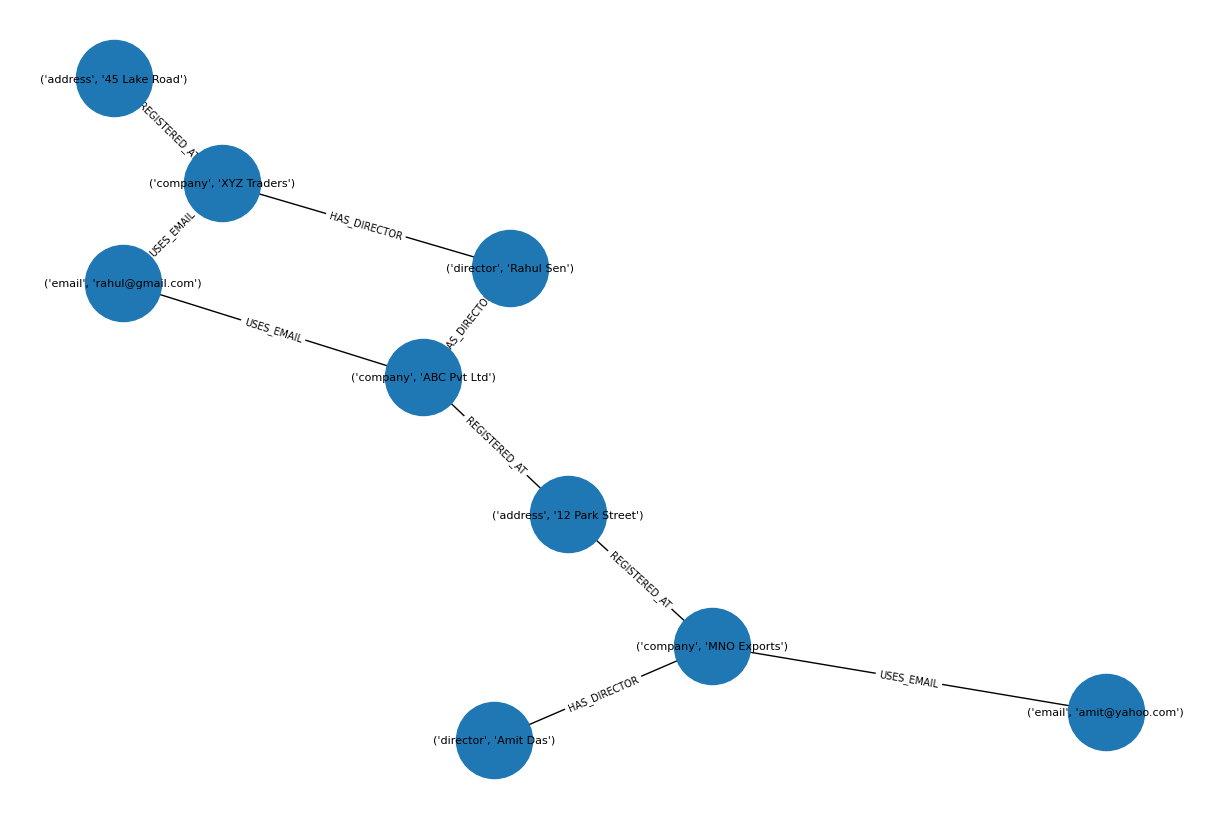

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    font_size=8
)

edge_labels = nx.get_edge_attributes(G, 'relation')

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=7
)

plt.show()

In [4]:
components = list(nx.connected_components(G))

for i, comp in enumerate(components):
    print(f"\nNetwork {i+1}")
    for node in comp:
        print(node)


Network 1
('company', 'MNO Exports')
('director', 'Amit Das')
('director', 'Rahul Sen')
('company', 'ABC Pvt Ltd')
('address', '12 Park Street')
('address', '45 Lake Road')
('company', 'XYZ Traders')
('email', 'amit@yahoo.com')
('email', 'rahul@gmail.com')


In [5]:
from collections import Counter

email_count = Counter(df["email"])

for email, cnt in email_count.items():
    if cnt > 1:
        print(f"Shared email detected: {email}")

Shared email detected: rahul@gmail.com


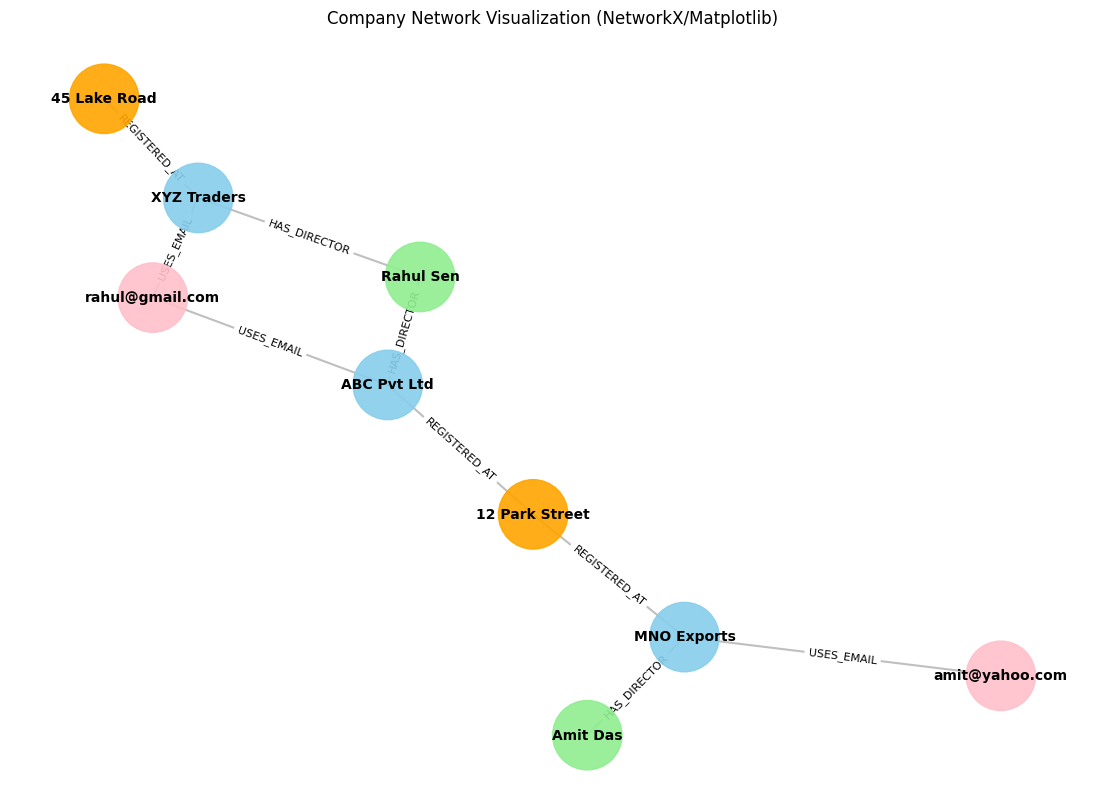

In [7]:
import matplotlib.pyplot as plt
import networkx as nx

# Create a figure for the plot
plt.figure(figsize=(14, 10))

# Calculate position for all nodes using a spring layout
pos = nx.spring_layout(G, k=0.5, seed=42)

# Define node colors based on their type
color_map = []
for node, attr in G.nodes(data=True):
    node_type = attr.get('type', '')
    if node_type == 'company':
        color_map.append('skyblue')
    elif node_type == 'director':
        color_map.append('lightgreen')
    elif node_type == 'address':
        color_map.append('orange')
    else:
        color_map.append('pink') # for email

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=2500, node_color=color_map, alpha=0.9)

# Draw edges
nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.5, edge_color='gray')

# Draw labels for nodes
labels = {node: node[1] for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_weight='bold')

# Draw edge labels
edge_labels = nx.get_edge_attributes(G, 'relation')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("Company Network Visualization (NetworkX/Matplotlib)")
plt.axis('off')
plt.show()

In [ ]:
!pip install pyvis